# Unit 2 | NLP 02 — Vectorization: CountVec, TF-IDF & Embeddings

Machine learning models need numbers. This notebook converts preprocessed text into numeric feature matrices using three approaches:

1. **CountVectorizer** — term frequency (bag of words)
2. **TF-IDF** — term frequency × inverse document frequency
3. **Sentence Embeddings** — dense semantic vectors from a pre-trained transformer

We'll explore hyperparameters, visualize each representation, and compare how well each captures meaning.

**Dataset:** sklearn 20 Newsgroups

In [1]:
import re
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
plt.style.use('dark_background')

In [2]:
# ── CONFIGURATION ────────────────────────────────────────────────────────────
CATEGORIES   = ['sci.space', 'comp.graphics', 'rec.sport.hockey', 'talk.religion.misc']
RANDOM_STATE = 42
MODEL_NAME   = 'all-MiniLM-L6-v2'   # fast, 384-dim — good for demos
DOCS_PER_CAT = 150                   # subsample for embedding section
cmap         = plt.cm.get_cmap('tab10', len(CATEGORIES))
# ─────────────────────────────────────────────────────────────────────────────

In [3]:
data = fetch_20newsgroups(
    subset='train',
    categories=CATEGORIES,
    remove=('headers', 'footers', 'quotes'),
    random_state=RANDOM_STATE
)

print(f"Training documents: {len(data.data):,}")
print(f"Categories: {data.target_names}")

Training documents: 2,154
Categories: ['comp.graphics', 'rec.sport.hockey', 'sci.space', 'talk.religion.misc']


## The Term-Document Matrix

The central idea of classical NLP feature extraction is the **term-document matrix**:

- Rows = documents
- Columns = vocabulary terms
- Cell (i, j) = some measure of how important term j is in document i

```
            space  rocket  hockey  puck
 doc_0          3       1       0     0
 doc_1          0       0       4     2
 doc_2          0       0       0     0
```

Two common ways to fill this matrix: **raw counts** (CountVectorizer) and **TF-IDF** (TfidfVectorizer).

## 1. CountVectorizer — Bag of Words

In [4]:
cv = CountVectorizer(
    max_features=5000,
    stop_words='english'
)
X = cv.fit_transform(data.data)
terms = cv.get_feature_names_out()

df_counts = pd.DataFrame(X.toarray(), columns=terms)
df_counts

,00,000,005,01,02,03,04,05,06,0666,07,08,09,10,100,1000,101,102,1020,103,1030,104,105,106,107,108,109,11,110,111,112,113,114,115,116,117,118,119,12,120,1200,121,122,123,124,125,126,127,128,129,...,wp,wpg,wrap,write,writer,writes,writing,writings,written,wrong,wrote,wsh,wuarchive,wustl,x11,xerox,xloadimage,xv,xxxx,xxxxx,ya,yake,yale,yawney,ye,yeah,year,years,yee,yep,yes,yesterday,york,young,youth,ysebaert,yushkevich,yzerman,zalapski,zelepukin,zero,zhamnov,zhitnik,zip,zombo,zone,zoroastrian,zoroastrianism,zoroastrians,zubov
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2149,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2150,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2151,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2152,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 2. Key Hyperparameters

CountVectorizer has several parameters that dramatically affect the feature matrix:

| Parameter | What it controls |
|---|---|
| `max_features` | Maximum vocabulary size (keeps most frequent terms) |
| `min_df` | Ignore terms that appear in fewer than N documents |
| `max_df` | Ignore terms that appear in more than N% of documents |
| `stop_words` | Built-in stopword list (`'english'`) |
| `ngram_range` | Include unigrams, bigrams, etc. e.g. `(1,2)` |

In [5]:
param_configs = {
    'Baseline (max_features=5000)': dict(max_features=5000),
    'No max_features':              dict(max_features=None),
    '+ stop_words':                 dict(max_features=None, stop_words='english'),
    '+ min_df=5':                   dict(max_features=None, stop_words='english', min_df=5),
    '+ bigrams (1,2)':              dict(max_features=None, stop_words='english', ngram_range=(1,2)),
}

print(f"{'Config':<40} {'Vocab Size':>12} {'Matrix Shape'}")
print('-' * 65)
for label, params in param_configs.items():
    cv_tmp = CountVectorizer(**params)
    X_tmp  = cv_tmp.fit_transform(data.data)
    print(f"{label:<40} {X_tmp.shape[1]:>12,}   {X_tmp.shape}")

Config                                     Vocab Size Matrix Shape
-----------------------------------------------------------------
Baseline (max_features=5000)                    5,000   (2154, 5000)
No max_features                                28,802   (2154, 28802)
+ stop_words                                   28,498   (2154, 28498)
+ min_df=5                                      5,753   (2154, 5753)
+ bigrams (1,2)                               208,657   (2154, 208657)


## 3. Top Terms by Raw Frequency

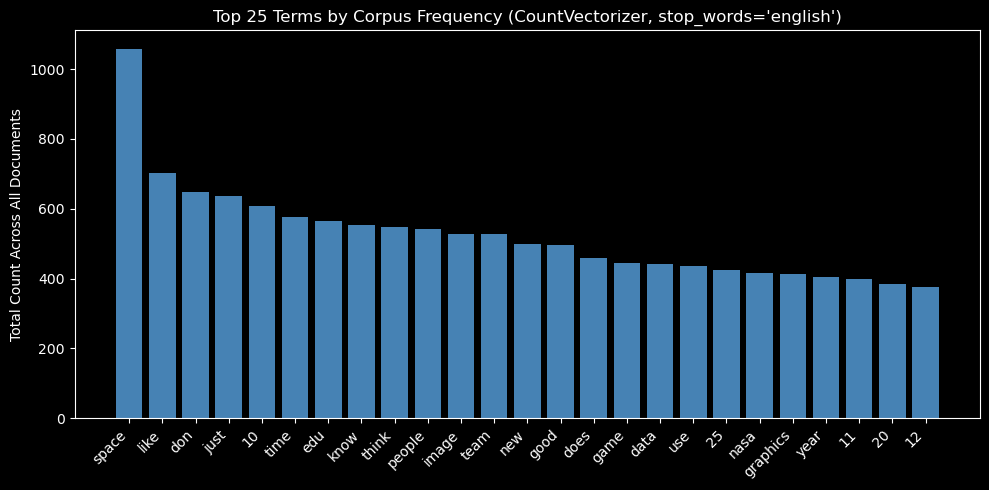

In [6]:
cv_vis = CountVectorizer(max_features=5000, stop_words='english')
X_vis  = cv_vis.fit_transform(data.data)
terms  = cv_vis.get_feature_names_out()
freqs  = np.asarray(X_vis.sum(axis=0)).ravel()

top_n = 25
top_idx   = freqs.argsort()[::-1][:top_n]
top_terms = terms[top_idx]
top_freqs = freqs[top_idx]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(top_n), top_freqs, color='steelblue')
ax.set_xticks(range(top_n))
ax.set_xticklabels(top_terms, rotation=45, ha='right')
ax.set_ylabel('Total Count Across All Documents')
ax.set_title(f"Top {top_n} Terms by Corpus Frequency (CountVectorizer, stop_words='english')")
plt.tight_layout()
plt.show()

## 4. TF-IDF — Term Frequency × Inverse Document Frequency

**The problem with raw counts:** Words like *write* or *use* appear often in many documents but tell us nothing specific about a newsgroup.

**TF-IDF** downweights terms that appear in many documents and upweights terms that are distinctive to a few:

$$
\text{TF-IDF}(t, d) =
\underbrace{\text{tf}(t,d)}_{\text{count in doc}} \cdot \hspace{5pt}
\underbrace{\log\Bigg(\frac{N+1}{\text{df}(t)+1} + 1\Bigg)}_{\text{rarity across corpus}}
$$

Where:
- $\text{tf}(t,d)$ = count of term $t$ in document $d$
- $N$ = total documents
- $\text{df}(t)$ = number of documents containing $t$

In [ ]:
tfidf = TfidfVectorizer(
    norm=None,
    lowercase=True,
    strip_accents='unicode',
    token_pattern=r"\b[\w\-']+\b",
    stop_words='english',
    min_df=5,
    max_df=0.75,
    max_features=5000,
)
X_tfidf = tfidf.fit_transform(data.data)
tfidf_terms = tfidf.get_feature_names_out()

df_tfidf = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_terms)
df_tfidf

,0,0-0,00,000,01,02,03,04,05,06,07,08,09,1,1--3,1-0,1-1,1-2,1-3,10,100,1000,101,102,1024x768,103,1030,104,105,106,107,108,109,11,110,111,112,113,114,115,116,117,118,119,12,120,1200,121,122,123,...,writing,writings,written,wrong,wrote,wuarchive,wustl,x,x-ray,x-windows,x11,x11r4,xv,y,ya,yake,yale,yawney,ye,yeah,year,year's,years,yee,yellow,yep,yes,yesterday,york,you'd,you'll,you're,you've,young,youth,ysebaert,yushkevich,yzerman,z,zalapski,zelepukin,zero,zeus,zhamnov,zhitnik,zip,zombo,zone,zoo,zubov
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.000000,15.035953,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.596104,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,3.46061,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2149,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
2150,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.922973,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.39888,0.0,0.0,0.0,0.0,5.967496,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,

In [8]:
df_tfidf.max().sort_values(ascending=False).head(20)

0         3907.030191
jpeg      1196.651186
2          910.142882
1          906.121743
25         842.173249
55         755.422464
_          604.949068
4          600.841426
pts        532.591205
14         519.176794
7          516.527158
pt         494.958328
image      482.590278
3          474.465634
6          471.187270
la         461.102561
ra         453.482500
8          440.600622
5          432.285265
launch     428.842317
dtype: float64

# CountVectorization and TFIDF Compared

In [9]:
vectorizer = CountVectorizer(
    lowercase=True,
    strip_accents='unicode',
    token_pattern=r"\b[\w\-']+\b",
    stop_words='english',
    min_df=5,
    max_df=0.75,
    max_features=5000,
)
X = vectorizer.fit_transform(data.data)
terms = vectorizer.get_feature_names_out()

df_counts = pd.DataFrame(X.toarray(), columns=terms)

In [10]:
N = 50

cv_top    = df_counts.mean().sort_values(ascending=False).head(N).reset_index()
tfidf_top = df_tfidf.mean().sort_values(ascending=False).head(N).reset_index()

cv_top.columns    = ['cv_term',    'cv_mean']
tfidf_top.columns = ['tfidf_term', 'tfidf_mean']

cv_top['cv_max']       = df_counts[cv_top['cv_term']].max().values
tfidf_top['tfidf_max'] = df_tfidf[tfidf_top['tfidf_term']].max().values

comparison = pd.concat([cv_top, tfidf_top], axis=1)
comparison

,cv_term,cv_mean,cv_max,tfidf_term,tfidf_mean,tfidf_max
0,1,1.483287,310,0,5.760886,3907.030191
1,0,1.465645,994,1,4.335608,906.121743
2,2,0.987001,309,2,2.907158,910.142882
3,3,0.675487,151,3,2.122487,474.465634
4,4,0.592386,180,4,1.977390,600.841426
5,space,0.466574,70,7,1.550817,516.527158
6,5,0.449861,128,5,1.519283,432.285265
7,7,0.411328,137,space,1.506478,226.016604
8,6,0.410399,132,6,1.464961,471.187270
9,8,0.331012,118,8,1.235967,440.600622


## Summary — CountVec vs TF-IDF

| | CountVectorizer | TfidfVectorizer |
|---|---|---|
| Values | Integer counts | Float weights |
| Common words | Rewarded (high count) | Penalized (IDF downweight) |
| Works with | Multinomial Naive Bayes | Logistic Regression, SVM |
| Best for | When raw frequency matters | Most text classification tasks |

Both representations treat every word as independent — "rocket" and "spacecraft" are as different as "rocket" and "philosophy". The next section introduces **sentence embeddings**, which map text into a continuous space where *meaning* determines proximity.

In [11]:
# Subsample: DOCS_PER_CAT documents per category (keeps encoding fast)
np.random.seed(RANDOM_STATE)
keep_idx = []
for cat_idx in range(len(CATEGORIES)):
    idx = np.where(data.target == cat_idx)[0]
    keep_idx.extend(np.random.choice(idx, size=min(DOCS_PER_CAT, len(idx)), replace=False))

docs        = [data.data[i][:1000] for i in keep_idx]   # cap at 1000 chars/doc
labels      = data.target[keep_idx]
label_names = [data.target_names[l] for l in labels]

print(f"Documents to embed: {len(docs)}")
print(f"Category breakdown: { {data.target_names[i]: int((labels==i).sum()) for i in range(len(CATEGORIES))} }")

Documents to embed: 600
Category breakdown: {'comp.graphics': 150, 'rec.sport.hockey': 150, 'sci.space': 150, 'talk.religion.misc': 150}


## 5. Why Bag-of-Words Fails for Semantics

Consider these two sentences:

| Sentence | CountVec overlap |
|---|---|
| "The rocket launched from the pad." | — |
| "The spacecraft lifted off from the platform." | 2 words (`the`, `from`) |

These sentences are **semantically identical** but share almost no vocabulary. CountVectorizer would treat them as very different documents.

Sentence embeddings solve this by learning a shared representation where *meaning* determines distance, not just word overlap.

## 6. Encoding Documents with SentenceTransformer

In [12]:
# Load the pre-trained model (downloads once, cached after)
model = SentenceTransformer(MODEL_NAME)
print(f"Model: {MODEL_NAME}")
print(f"Embedding dimension: {model.get_sentence_embedding_dimension()}")
print()

# Encode — show_progress_bar gives feedback on longer batches
embeddings = model.encode(docs, show_progress_bar=True, batch_size=64)

print(f"\nEmbedding matrix shape: {embeddings.shape}")
print(f"Each document → a {embeddings.shape[1]}-dimensional vector")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Model: all-MiniLM-L6-v2
Embedding dimension: 384



Batches:   0%|          | 0/10 [00:00<?, ?it/s]


Embedding matrix shape: (600, 384)
Each document → a 384-dimensional vector


## 7. Semantic Similarity

We can measure how similar two documents are by computing the **cosine similarity** of their embeddings:

$$\text{cosine}(\mathbf{a}, \mathbf{b}) = \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\| \|\mathbf{b}\|}$$

Values range from −1 (opposite meaning) to +1 (identical meaning).

In [13]:
query_idx  = 0
query_doc  = docs[query_idx]
query_cat  = label_names[query_idx]

print(f"Query ({query_cat}):")
print(query_doc[:300])
print()

sim = cosine_similarity([embeddings[query_idx]], embeddings)[0]

top5_idx = sim.argsort()[::-1][1:6]    # skip self (index 0)
bot5_idx = sim.argsort()[:5]

print("Top 5 MOST similar documents:")
for rank, i in enumerate(top5_idx, 1):
    print(f"  [{rank}] sim={sim[i]:.3f}  cat={label_names[i]}")
    print(f"      {docs[i][:120]}\n")

print("\nTop 5 LEAST similar documents:")
for rank, i in enumerate(bot5_idx, 1):
    print(f"  [{rank}] sim={sim[i]:.3f}  cat={label_names[i]}")
    print(f"      {docs[i][:120]}\n")

Query (comp.graphics):
The real problem w/ the Stealth from what I've heard is that Diamond won't
tell anyone how to program their proprietary clock stuff, so X under Linux
and 386BSD won't run....


Top 5 MOST similar documents:
  [1] sim=0.367  cat=comp.graphics
      Visual Numerics Inc. (formerly IMSL and Precision Visuals) is in the
process of securing sites for beta testing X Expone

  [2] sim=0.352  cat=comp.graphics
      I would like to program Tseng ET4000 to nonstandard 1024x768 mode by
switching to standard 1024x768 mode using BIOS and 

  [3] sim=0.336  cat=comp.graphics
      
The RS6000 compiler is so forgiving, I think that if you mixed COBOL & pascal
the C compiler still wouldn't complain. :

  [4] sim=0.329  cat=comp.graphics
      Organization: "A World of Information at your Fingertips"
Keywords: 



Craig,

You should still consider the Targa+. I 

  [5] sim=0.328  cat=comp.graphics
      : There is a new version of the RTrace ray-tracing package (8.2.0) at
: aster

## 8. Visualization

**Principal Component Analysis (PCA)** linearly projects high-dimensional embeddings into 2D. It preserves global variance — clusters that are far apart in 384 dimensions stay far apart in 2D.

**t-SNE** is a non-linear dimensionality reduction algorithm that prioritizes preserving *local* structure — points that are close in high-dimensional space end up close in 2D. It often produces cleaner clusters than PCA for embeddings, but:

- It is slower
- The global layout (which cluster is near which) is not meaningful
- Results vary with `perplexity`

Variance explained by PC1: 6.1%
Variance explained by PC2: 4.7%
Total: 10.7%


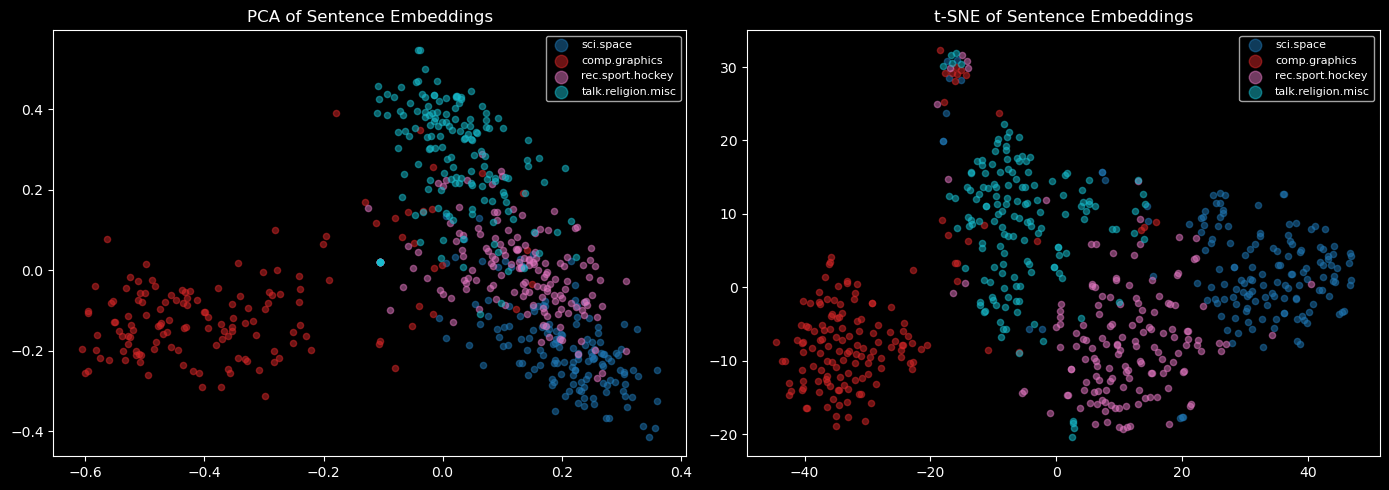

In [14]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
emb_2d_pca = pca.fit_transform(embeddings)

print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]:.1%}")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]:.1%}")
print(f"Total: {pca.explained_variance_ratio_.sum():.1%}")

tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE)
emb_2d_tsne = tsne.fit_transform(embeddings)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
titles = ['PCA', 't-SNE']
coords = [emb_2d_pca, emb_2d_tsne]

for ax, title, xy in zip(axes, titles, coords):
    for cat_idx, cat in enumerate(CATEGORIES):
        mask = labels == cat_idx
        ax.scatter(xy[mask, 0], xy[mask, 1],
                   label=cat, alpha=0.5, s=20, color=cmap(cat_idx))
    ax.set_title(f'{title} of Sentence Embeddings')
    ax.legend(markerscale=2, fontsize=8)

plt.tight_layout()
plt.show()

### Compare Embeddings with BoW Vectorization

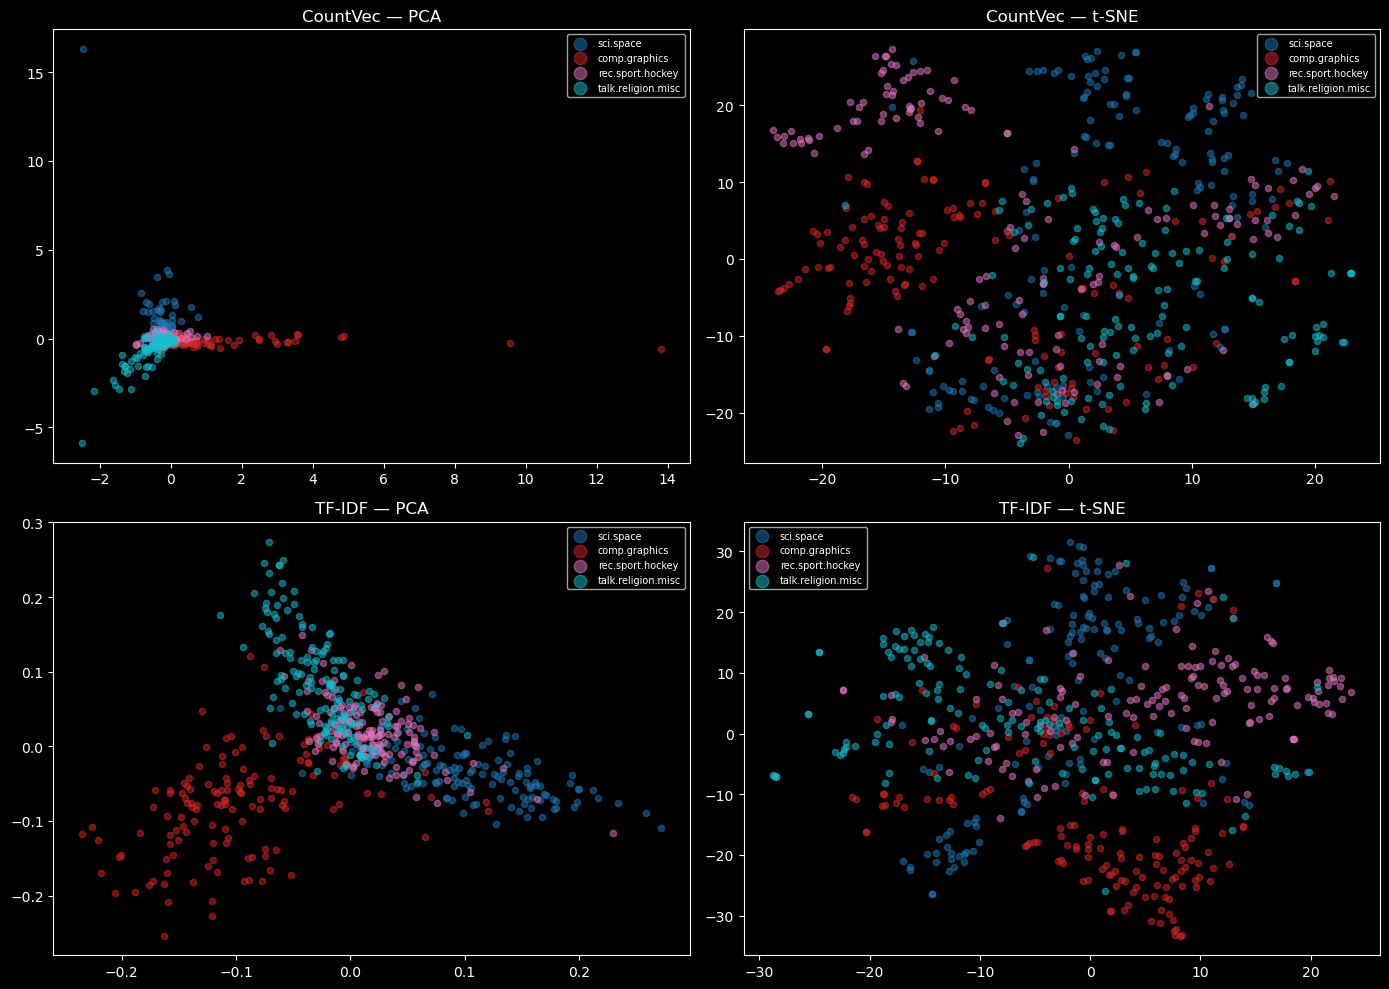

In [15]:
viz_vectorizers = {
    'CountVec': CountVectorizer(max_features=5000, stop_words='english', ngram_range=(1,1), min_df=2),
    'TF-IDF':   TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,1), min_df=2, sublinear_tf=True),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row, (vec_name, vec) in enumerate(viz_vectorizers.items()):
    X_viz = vec.fit_transform(docs).toarray()

    pca_viz   = PCA(n_components=20, random_state=RANDOM_STATE)
    X_viz_20  = pca_viz.fit_transform(X_viz)
    X_viz_pca = X_viz_20[:, :2]  # first 2 PCs for plotting

    tsne_viz   = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE)
    X_viz_tsne = tsne_viz.fit_transform(X_viz_20)

    for col, (title, xy) in enumerate(zip(['PCA', 't-SNE'], [X_viz_pca, X_viz_tsne])):
        ax = axes[row, col]
        for cat_idx, cat in enumerate(CATEGORIES):
            mask = labels == cat_idx
            ax.scatter(xy[mask, 0], xy[mask, 1],
                   label=cat, alpha=0.5, s=20, color=cmap(cat_idx))
        ax.set_title(f'{vec_name} — {title}')
        ax.legend(markerscale=2, fontsize=7)

plt.tight_layout()
plt.show()

## Summary

| | Bag-of-Words | Sentence Embeddings |
|---|---|---|
| Representation | Sparse, high-dim (vocab size) | Dense, fixed-dim (e.g. 384) |
| Captures synonyms | No | Yes |
| Captures word order | No | Partially |
| Training data needed | No (fit on corpus) | No (pre-trained) |
| Interpretability | High (features are words) | Low (features are latent dims) |
| Speed | Fast | Slower (transformer inference) |

**Next →** Notebook 3 builds classification pipelines using all three representations.